# 08j — Final Multi-Objective Decision-Support Ranking

This notebook provides the final descriptive integration for PEARL Pipeline 4. Energy, structural and developability evidence remain visible as separate domains. The composite score is a configurable decision-support heuristic—not binding affinity, experimental solubility, a validated Bayesian posterior or proof of superiority.

With two evaluated candidates, raw values, Pareto trade-offs and weight sensitivity are more informative than the rank alone.

## 1. Configuration

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/Users/robertobruzzese/Desktop/venv')
OUTPUTS_ROOT = PROJECT_ROOT / 'outputs'
P08I = OUTPUTS_ROOT / 'pipeline_4_ai_08i_bayesian_optimisation/tables/08i_observed_integrated_evidence.csv'
P08I_SENSITIVITY = OUTPUTS_ROOT / 'pipeline_4_ai_08i_bayesian_optimisation/tables/08i_weight_sensitivity.csv'
P08I_PROPOSALS = OUTPUTS_ROOT / 'pipeline_4_ai_08i_bayesian_optimisation/tables/08i_proposed_candidates.csv'
P08I_READINESS = OUTPUTS_ROOT / 'pipeline_4_ai_08i_bayesian_optimisation/tables/08i_botorch_readiness.csv'

OUTPUT_ROOT = OUTPUTS_ROOT / 'pipeline_4_ai_08j_final_multiobjective'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIGURE_DIR = OUTPUT_ROOT / 'figures'
PROVENANCE_DIR = OUTPUT_ROOT / 'provenance'
for directory in (TABLE_DIR, FIGURE_DIR, PROVENANCE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

FINAL_WEIGHTS = {
    'energy_utility_z': 1 / 3,
    'structural_utility_z': 1 / 3,
    'developability_utility_z': 1 / 3,
}
TIE_TOLERANCE = 1e-10
RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).isoformat()

for label, path in {
    '08i integrated evidence': P08I,
    '08i weight sensitivity': P08I_SENSITIVITY,
    '08i proposals': P08I_PROPOSALS,
    '08i readiness': P08I_READINESS,
}.items():
    print(label, '->', path, '| exists:', path.exists())

08i integrated evidence -> /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_observed_integrated_evidence.csv | exists: True
08i weight sensitivity -> /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_weight_sensitivity.csv | exists: True
08i proposals -> /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_proposed_candidates.csv | exists: True
08i readiness -> /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_botorch_readiness.csv | exists: True


## 2. Load and validate the 08i evidence contract

08j consumes the harmonised evidence produced by 08i rather than independently re-merging upstream tables. All required domain utilities and their raw supporting measurements must be present and finite.

In [2]:
required_files = {
    'integrated evidence': P08I,
    'weight sensitivity': P08I_SENSITIVITY,
    'proposal status': P08I_PROPOSALS,
    'BoTorch readiness': P08I_READINESS,
}
missing_files = [f'{name}: {path}' for name, path in required_files.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError('Required 08j inputs are missing:\n' + '\n'.join(missing_files))

df = pd.read_csv(P08I)
sensitivity = pd.read_csv(P08I_SENSITIVITY)
proposals = pd.read_csv(P08I_PROPOSALS)
readiness = pd.read_csv(P08I_READINESS)

required_columns = {
    'candidate_id', 'sequence', 'sequence_sha256',
    'mean_delta_E_endpoint_kcal_mol', 'sd_delta_E_endpoint_kcal_mol',
    'mean_pLDDT', 'global_CA_RMSD_A',
    'developability_metric_value', 'developability_metric_used',
    'developability_metric_source',
    'developability_metric_higher_is_better',
    'camsol_executed', 'camsol_result_validated', 'camsol_overall_score',
    'energy_utility_z', 'structural_utility_z',
    'developability_utility_z',
}
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f'08i integrated evidence lacks columns: {sorted(missing)}')
if df.empty:
    raise ValueError('08i integrated evidence is empty')
if df['candidate_id'].isna().any() or df['sequence'].isna().any():
    raise ValueError('Null candidate_id or sequence detected')
df['candidate_id'] = df['candidate_id'].astype(str).str.strip()
df['sequence'] = df['sequence'].astype(str).str.upper().str.replace(r'\s+', '', regex=True)
if df['candidate_id'].duplicated().any():
    raise ValueError('Duplicated candidate_id in 08i evidence')
calculated_hash = df['sequence'].map(
    lambda sequence: hashlib.sha256(sequence.encode('utf-8')).hexdigest()
)
if not df['sequence_sha256'].astype(str).eq(calculated_hash).all():
    raise ValueError('Sequence hash mismatch in 08i evidence')

numeric_columns = [
    'mean_delta_E_endpoint_kcal_mol', 'sd_delta_E_endpoint_kcal_mol',
    'mean_pLDDT', 'global_CA_RMSD_A', 'developability_metric_value',
    'energy_utility_z', 'structural_utility_z', 'developability_utility_z',
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='raise')
if not np.isfinite(df[numeric_columns].to_numpy(dtype=float)).all():
    raise ValueError('Required 08j evidence contains NaN or infinity')

if not np.isclose(sum(FINAL_WEIGHTS.values()), 1.0):
    raise ValueError('FINAL_WEIGHTS must sum to one')
if set(FINAL_WEIGHTS) != {'energy_utility_z', 'structural_utility_z', 'developability_utility_z'}:
    raise ValueError('FINAL_WEIGHTS must contain exactly the three domain utilities')

display(df)

,candidate_id,sequence,sequence_sha256,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,foldx_interaction_energy_kcal_mol,best_I_sc,...,developability_metric_source,developability_metric_higher_is_better,developability_metric_value,energy_utility_z,plddt_utility_z,global_rmsd_utility_z,structural_utility_z,developability_utility_z,observed_composite_proxy,exploratory_rank
0,MPNN_NEW_01,TGPRNQYRDLP,2aabd4dfdefe34755b3409eb7c510495268239b597adac...,-46.408438,4.655577,0.601249,-3.172003,1.2473,-11.7407,-54.169,...,sequence-derived Biopython GRAVY proxy,False,-1.936364,-1.0,1.0,1.0,1.0,1.0,0.333333,1
1,MPNN_NEW_05,IGPRHQYRDLP,2c7e843423076b0f54d2ed351fcbdf120d8cb3d3a5da9c...,-53.673748,6.427169,0.508830,-3.174593,1.4079,-13.7478,-56.118,...,sequence-derived Biopython GRAVY proxy,False,-1.436364,1.0,-1.0,-1.0,-1.0,-1.0,-0.333333,2


## 3. Final configurable composite

The default gives equal weight to the three evidence domains. Structural pLDDT and RMSD were already combined by 08i into one structural-domain utility, preventing structure from receiving twice the weight merely because two structural descriptors are available.

In [3]:
df['final_composite_score'] = sum(
    weight * df[column] for column, weight in FINAL_WEIGHTS.items()
)
df['final_rank'] = df['final_composite_score'].rank(
    ascending=False, method='min', na_option='bottom'
).astype('Int64')
df = df.sort_values(['final_rank', 'candidate_id']).reset_index(drop=True)

display_columns = [
    'final_rank', 'candidate_id', 'sequence',
    'mean_delta_E_endpoint_kcal_mol', 'sd_delta_E_endpoint_kcal_mol',
    'mean_pLDDT', 'global_CA_RMSD_A',
    'developability_metric_value', 'developability_metric_used',
    'developability_metric_source', 'energy_utility_z',
    'structural_utility_z', 'developability_utility_z',
    'final_composite_score',
]
display(df[display_columns])

,final_rank,candidate_id,sequence,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,mean_pLDDT,global_CA_RMSD_A,developability_metric_value,developability_metric_used,developability_metric_source,energy_utility_z,structural_utility_z,developability_utility_z,final_composite_score
0,1,MPNN_NEW_01,TGPRNQYRDLP,-46.408438,4.655577,72.559091,4.486997,-1.936364,proxy_gravy,sequence-derived Biopython GRAVY proxy,-1.0,1.0,1.0,0.333333
1,2,MPNN_NEW_05,IGPRHQYRDLP,-53.673748,6.427169,67.273636,5.073322,-1.436364,proxy_gravy,sequence-derived Biopython GRAVY proxy,1.0,-1.0,-1.0,-0.333333


## 4. Pareto analysis

A candidate is Pareto-dominated only if another candidate is at least as good in every utility domain and strictly better in at least one. Pareto status is independent of the chosen composite weights.

In [4]:
utility_columns = [
    'energy_utility_z', 'structural_utility_z', 'developability_utility_z'
]
utilities = df[utility_columns].to_numpy(dtype=float)
pareto_dominated = np.zeros(len(df), dtype=bool)
dominated_by = [[] for _ in range(len(df))]
for i in range(len(df)):
    for j in range(len(df)):
        if i == j:
            continue
        at_least_as_good = np.all(utilities[j] >= utilities[i] - TIE_TOLERANCE)
        strictly_better = np.any(utilities[j] > utilities[i] + TIE_TOLERANCE)
        if at_least_as_good and strictly_better:
            pareto_dominated[i] = True
            dominated_by[i].append(df.loc[j, 'candidate_id'])
df['pareto_optimal'] = ~pareto_dominated
df['dominated_by'] = [';'.join(values) for values in dominated_by]
display(df[[
    'candidate_id', *utility_columns, 'pareto_optimal', 'dominated_by'
]])

,candidate_id,energy_utility_z,structural_utility_z,developability_utility_z,pareto_optimal,dominated_by
0,MPNN_NEW_01,-1.0,1.0,1.0,True,
1,MPNN_NEW_05,1.0,-1.0,-1.0,True,


## 5. Weight sensitivity, outright wins and ties

A scenario can have more than one rank-1 candidate. Such cases are counted as ties for first—not as independent outright victories.

In [5]:
sensitivity_required = {
    'scenario', 'candidate_id', 'weight_energy', 'weight_structure',
    'weight_developability', 'composite_score', 'rank',
}
missing = sensitivity_required - set(sensitivity.columns)
if missing:
    raise ValueError(f'08i sensitivity table lacks columns: {sorted(missing)}')
if set(sensitivity['candidate_id']) != set(df['candidate_id']):
    raise ValueError('Sensitivity candidate cohort differs from integrated evidence')
for column in ['weight_energy', 'weight_structure', 'weight_developability', 'composite_score']:
    sensitivity[column] = pd.to_numeric(sensitivity[column], errors='raise')

scenario_results = []
candidate_stats = {
    candidate_id: {'outright_wins': 0, 'ties_for_first': 0, 'losses': 0}
    for candidate_id in df['candidate_id']
}
for scenario, group in sensitivity.groupby('scenario', sort=True):
    maximum = group['composite_score'].max()
    winner_mask = np.isclose(
        group['composite_score'], maximum, atol=TIE_TOLERANCE, rtol=0
    )
    winners = sorted(group.loc[winner_mask, 'candidate_id'].tolist())
    outcome = 'tie_for_first' if len(winners) > 1 else 'outright_win'
    scenario_results.append({
        'scenario': scenario,
        'outcome': outcome,
        'winner_ids': ';'.join(winners),
        'winning_score': maximum,
        'weight_energy': group['weight_energy'].iloc[0],
        'weight_structure': group['weight_structure'].iloc[0],
        'weight_developability': group['weight_developability'].iloc[0],
    })
    for candidate_id in candidate_stats:
        if candidate_id in winners:
            key = 'ties_for_first' if len(winners) > 1 else 'outright_wins'
            candidate_stats[candidate_id][key] += 1
        else:
            candidate_stats[candidate_id]['losses'] += 1

scenario_summary = pd.DataFrame(scenario_results)
robustness = pd.DataFrame([
    {'candidate_id': candidate_id, **statistics}
    for candidate_id, statistics in candidate_stats.items()
])
robustness['scenarios_ranked_first'] = (
    robustness['outright_wins'] + robustness['ties_for_first']
)
robustness['total_scenarios'] = sensitivity['scenario'].nunique()
df = df.merge(robustness, on='candidate_id', how='left', validate='one_to_one')
display(scenario_summary)
display(robustness.sort_values([
    'outright_wins', 'ties_for_first', 'candidate_id'
], ascending=[False, False, True]))

,scenario,outcome,winner_ids,winning_score,weight_energy,weight_structure,weight_developability
0,developability_priority,outright_win,MPNN_NEW_01,5.000000e-01,0.250000,0.250000,0.500000
1,energy_priority,tie_for_first,MPNN_NEW_01;MPNN_NEW_05,3.330669e-16,0.500000,0.250000,0.250000
2,equal_domains,outright_win,MPNN_NEW_01,3.333333e-01,0.333333,0.333333,0.333333
3,structure_priority,outright_win,MPNN_NEW_01,5.000000e-01,0.250000,0.500000,0.250000


,candidate_id,outright_wins,ties_for_first,losses,scenarios_ranked_first,total_scenarios
0,MPNN_NEW_01,3,1,0,4,4
1,MPNN_NEW_05,0,1,3,1,4


## 6. Evidence-aware interpretation

Labels below summarize the observed trade-off; they do not convert the composite into a physical or experimental prediction.

In [6]:
energy_best = set(df.loc[
    np.isclose(
        df['mean_delta_E_endpoint_kcal_mol'],
        df['mean_delta_E_endpoint_kcal_mol'].min(),
        atol=TIE_TOLERANCE, rtol=0,
    ), 'candidate_id'
])
balanced_best = set(df.loc[df['final_rank'].eq(df['final_rank'].min()), 'candidate_id'])

def interpretation_label(row):
    candidate_id = row['candidate_id']
    labels = []
    if candidate_id in balanced_best:
        labels.append('best_equal-weight_exploratory_balance')
    if candidate_id in energy_best:
        labels.append('endpoint-energy-favoured')
    if row['pareto_optimal']:
        labels.append('pareto-optimal')
    if row['outright_wins'] > 0:
        labels.append('wins_one_or_more_weight_scenarios')
    if row['ties_for_first'] > 0:
        labels.append('ties_for_first_in_one_or_more_scenarios')
    return ';'.join(labels)

df['decision_support_label'] = df.apply(interpretation_label, axis=1)
display(df[[
    'final_rank', 'candidate_id', 'final_composite_score',
    'pareto_optimal', 'outright_wins', 'ties_for_first', 'losses',
    'decision_support_label',
]])

,final_rank,candidate_id,final_composite_score,pareto_optimal,outright_wins,ties_for_first,losses,decision_support_label
0,1,MPNN_NEW_01,0.333333,True,3,1,0,best_equal-weight_exploratory_balance;pareto-o...
1,2,MPNN_NEW_05,-0.333333,True,0,1,3,endpoint-energy-favoured;pareto-optimal;ties_f...


## 7. Status of CamSol and Bayesian optimisation

In [7]:
camsol_used = bool(
    df['camsol_executed'].astype(bool).all()
    and df['camsol_result_validated'].astype(bool).all()
    and df['camsol_overall_score'].notna().all()
)
developability_sources = sorted(df['developability_metric_source'].astype(str).unique())
developability_metrics = sorted(df['developability_metric_used'].astype(str).unique())

if 'bo_status' not in proposals.columns or proposals.empty:
    raise ValueError('08i proposal table does not report bo_status')
bo_status_values = proposals['bo_status'].dropna().astype(str).unique()
if len(bo_status_values) != 1:
    raise ValueError('Expected exactly one explicit Bayesian-optimisation status')
bo_status = bo_status_values[0]
new_sequence_proposed = bool(
    'sequence' in proposals.columns and proposals['sequence'].notna().any()
)

status = pd.DataFrame([
    {'evidence_class': 'developability', 'status': '; '.join(developability_metrics), 'provenance': '; '.join(developability_sources)},
    {'evidence_class': 'CamSol', 'status': 'executed_and_validated' if camsol_used else 'not_executed', 'provenance': '08h'},
    {'evidence_class': 'Bayesian optimisation', 'status': bo_status, 'provenance': '08i'},
    {'evidence_class': 'new sequence proposal', 'status': 'present' if new_sequence_proposed else 'not_proposed', 'provenance': '08i'},
])
display(status)

,evidence_class,status,provenance
0,developability,proxy_gravy,sequence-derived Biopython GRAVY proxy
1,CamSol,not_executed,08h
2,Bayesian optimisation,not_run_readiness_requirements_not_met,08i
3,new sequence proposal,not_proposed,08i


## 8. Figures, quality control and final outputs

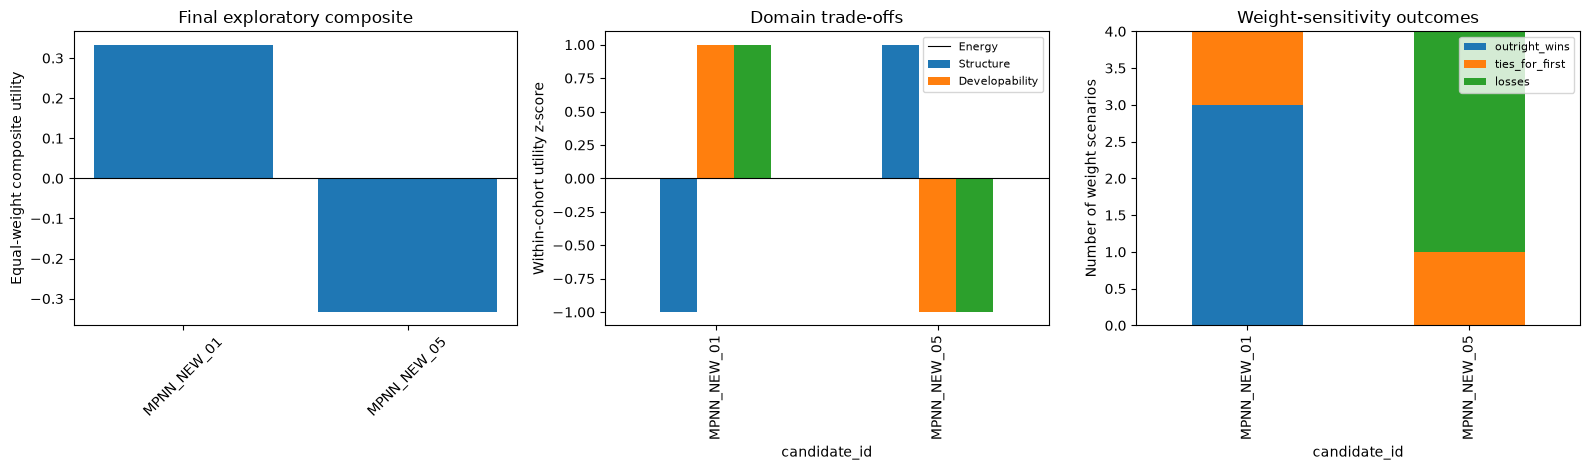

,check,pass,details
0,all_required_08i_inputs_exist,True,
1,candidate_ids_unique,True,n=2
2,sequence_hashes_validated,True,
3,three_domain_utilities_present,True,energy_utility_z; structural_utility_z; develo...
4,weights_sum_to_one,True,"{""energy_utility_z"": 0.3333333333333333, ""stru..."
5,all_candidates_have_rank,True,
6,pareto_status_complete,True,
7,sensitivity_outcomes_complete,True,scenarios=4
8,sensitivity_accounting_consistent,True,
9,developability_provenance_explicit,True,sequence-derived Biopython GRAVY proxy


ALL QC PASSED: True
Final ranking: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08j_final_multiobjective/tables/08j_final_multiobjective_ranking.csv
Equal-weight leader(s): ['MPNN_NEW_01']
Endpoint-energy-favoured: ['MPNN_NEW_05']
Pareto-optimal: ['MPNN_NEW_01', 'MPNN_NEW_05']


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_df = df.sort_values('final_rank')
axes[0].bar(plot_df['candidate_id'], plot_df['final_composite_score'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Equal-weight composite utility')
axes[0].set_title('Final exploratory composite')
axes[0].tick_params(axis='x', rotation=45)

plot_df.set_index('candidate_id')[[
    'energy_utility_z', 'structural_utility_z', 'developability_utility_z'
]].plot(kind='bar', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Within-cohort utility z-score')
axes[1].set_title('Domain trade-offs')
axes[1].legend(['Energy', 'Structure', 'Developability'], fontsize=8)

robust_plot = robustness.sort_values('candidate_id').set_index('candidate_id')
robust_plot[['outright_wins', 'ties_for_first', 'losses']].plot(
    kind='bar', stacked=True, ax=axes[2]
)
axes[2].set_ylabel('Number of weight scenarios')
axes[2].set_title('Weight-sensitivity outcomes')
axes[2].legend(fontsize=8)
fig.tight_layout()
figure_path = FIGURE_DIR / '08j_final_multiobjective_summary.png'
fig.savefig(figure_path, dpi=220, bbox_inches='tight')
plt.show()

validated_hash_current = df['sequence'].map(
    lambda sequence: hashlib.sha256(sequence.encode('utf-8')).hexdigest()
)
camsol_consistent = (
    (~df['camsol_executed'].astype(bool) & ~df['camsol_result_validated'].astype(bool) & df['camsol_overall_score'].isna())
    |
    (df['camsol_executed'].astype(bool) & df['camsol_result_validated'].astype(bool) & df['camsol_overall_score'].notna())
)
qc = pd.DataFrame([
    {'check': 'all_required_08i_inputs_exist', 'pass': all(path.exists() for path in required_files.values()), 'details': ''},
    {'check': 'candidate_ids_unique', 'pass': not df['candidate_id'].duplicated().any(), 'details': f'n={len(df)}'},
    {'check': 'sequence_hashes_validated', 'pass': bool(df['sequence_sha256'].astype(str).eq(validated_hash_current).all()), 'details': ''},
    {'check': 'three_domain_utilities_present', 'pass': bool(np.isfinite(df[utility_columns].to_numpy(dtype=float)).all()), 'details': '; '.join(utility_columns)},
    {'check': 'weights_sum_to_one', 'pass': bool(np.isclose(sum(FINAL_WEIGHTS.values()), 1.0)), 'details': json.dumps(FINAL_WEIGHTS)},
    {'check': 'all_candidates_have_rank', 'pass': bool(df['final_rank'].notna().all()), 'details': ''},
    {'check': 'pareto_status_complete', 'pass': bool(df['pareto_optimal'].notna().all()), 'details': ''},
    {'check': 'sensitivity_outcomes_complete', 'pass': len(scenario_summary) == sensitivity['scenario'].nunique(), 'details': f"scenarios={sensitivity['scenario'].nunique()}"},
    {'check': 'sensitivity_accounting_consistent', 'pass': bool(((robustness['outright_wins'] + robustness['ties_for_first'] + robustness['losses']) == robustness['total_scenarios']).all()), 'details': ''},
    {'check': 'developability_provenance_explicit', 'pass': bool(df['developability_metric_source'].notna().all()), 'details': '; '.join(developability_sources)},
    {'check': 'camsol_state_consistent', 'pass': bool(camsol_consistent.all()), 'details': 'executed' if camsol_used else 'not_executed'},
    {'check': 'bo_status_explicit', 'pass': bool(bo_status), 'details': bo_status},
    {'check': 'no_unreported_sequence_proposal', 'pass': not new_sequence_proposed, 'details': 'No sequence claimed by 08j'},
])
qc.to_csv(TABLE_DIR / '08j_QC.csv', index=False)
display(qc)
if not qc['pass'].all():
    raise RuntimeError('08j QC failed:\n' + qc.loc[~qc['pass']].to_string(index=False))

ranking_path = TABLE_DIR / '08j_final_multiobjective_ranking.csv'
scenario_path = TABLE_DIR / '08j_weight_scenario_outcomes.csv'
robustness_path = TABLE_DIR / '08j_candidate_robustness.csv'
status_path = TABLE_DIR / '08j_evidence_status.csv'
df.to_csv(ranking_path, index=False)
scenario_summary.to_csv(scenario_path, index=False)
robustness.to_csv(robustness_path, index=False)
status.to_csv(status_path, index=False)

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

provenance = {
    'notebook': '08j_Final_Multi_Objective_Ranking.ipynb',
    'run_timestamp_utc': RUN_TIMESTAMP_UTC,
    'python_version': platform.python_version(),
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__,
    'inputs': {name: {'path': str(path), 'sha256': file_sha256(path)} for name, path in required_files.items()},
    'candidate_count': int(len(df)),
    'final_weights': FINAL_WEIGHTS,
    'tie_tolerance': TIE_TOLERANCE,
    'developability_metrics': developability_metrics,
    'developability_sources': developability_sources,
    'camsol_used': camsol_used,
    'botorch_status': bo_status,
    'new_sequence_proposed': new_sequence_proposed,
    'interpretation': 'Final exploratory multi-objective decision support; not affinity, experimental solubility or Bayesian posterior.',
}
(PROVENANCE_DIR / '08j_provenance.json').write_text(
    json.dumps(provenance, indent=2), encoding='utf-8'
)

top_ids = df.loc[df['final_rank'].eq(df['final_rank'].min()), 'candidate_id'].tolist()
energy_ids = sorted(energy_best)
pareto_ids = df.loc[df['pareto_optimal'], 'candidate_id'].tolist()
report = f'''# 08j final multi-objective report

- Candidates evaluated: {len(df)}
- Equal-weight exploratory leader(s): {', '.join(top_ids)}
- Endpoint-energy-favoured candidate(s): {', '.join(energy_ids)}
- Pareto-optimal candidate(s): {', '.join(pareto_ids)}
- Developability metric: {', '.join(developability_metrics)}
- Developability provenance: {', '.join(developability_sources)}
- CamSol used: {camsol_used}
- Bayesian-optimisation status: {bo_status}
- New sequence proposed: {new_sequence_proposed}

The ranking is a configurable decision-support heuristic. With two candidates, within-cohort z-scores primarily encode ordering and the result is sensitive to domain weights. It is not a binding-affinity estimate, experimental solubility measurement or validated Bayesian posterior. Raw energetic, structural and developability values must accompany any reported rank.
'''
(OUTPUT_ROOT / '08j_final_report.md').write_text(report, encoding='utf-8')

print('ALL QC PASSED:', bool(qc['pass'].all()))
print('Final ranking:', ranking_path)
print('Equal-weight leader(s):', top_ids)
print('Endpoint-energy-favoured:', energy_ids)
print('Pareto-optimal:', pareto_ids)

## 9. Reporting boundary

The final report should state that the equal-weight composite favours the best observed balance, while domain-specific alternatives remain visible. A candidate that is Pareto-optimal must not be described as universally superior: Pareto optimality means only that no evaluated candidate is better in every included domain.